<a href="https://colab.research.google.com/github/jorgefbarreiros/codes/blob/main/pe_hankt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SS EGM converged in 981 iterations.
Solving transitions for 21 alpha values.


/tmp/ipykernel_2162/2048912210.py:606: RuntimeWarning: divide by zero encountered in log
  np.log(G1[group][t]) - np.log(G0[group][t])
/tmp/ipykernel_2162/2048912210.py:606: RuntimeWarning: invalid value encountered in scalar subtract
  np.log(G1[group][t]) - np.log(G0[group][t])



Main summary:


,scenario,impact_C,impact_relative_to_flat,trough_C,cumulative_C_loss,avg_alpha,avg_alpha_cweighted,tariff_burden_stat,suff_cweighted,cov_iMPC_alpha_cweighted
0,flat,-0.649813,1.000000,-0.649813,-4.156619,0.11,0.110000,0.135862,0.003412,0.000000
1,mild_pro_poor,-0.642270,0.988391,-0.642270,-4.160901,0.11,0.109513,0.135261,0.003767,0.000299
2,strong_pro_poor,-0.629540,0.968801,-0.629540,-4.155685,0.11,0.108721,0.134283,0.004249,0.000710
3,pro_rich,-0.658297,1.013056,-0.658297,-4.157327,0.11,0.110559,0.136553,0.003076,-0.000287


Saved: pe_figures/pe_alpha_profiles.png


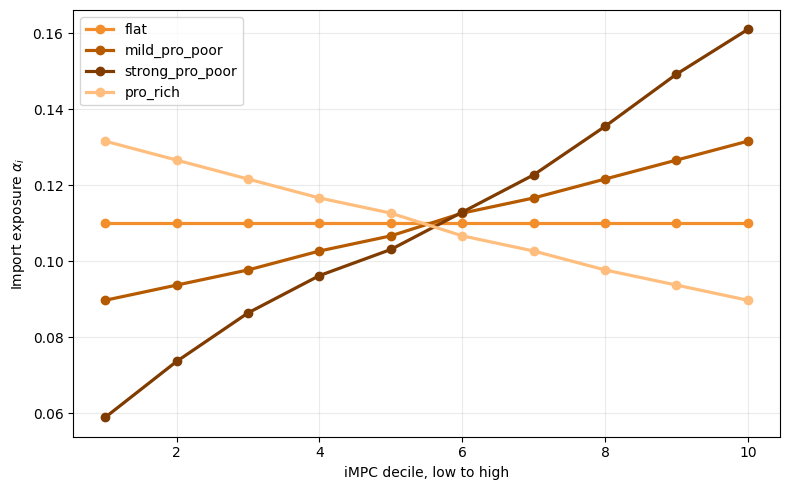

Saved: pe_figures/pe_tariff_path.png


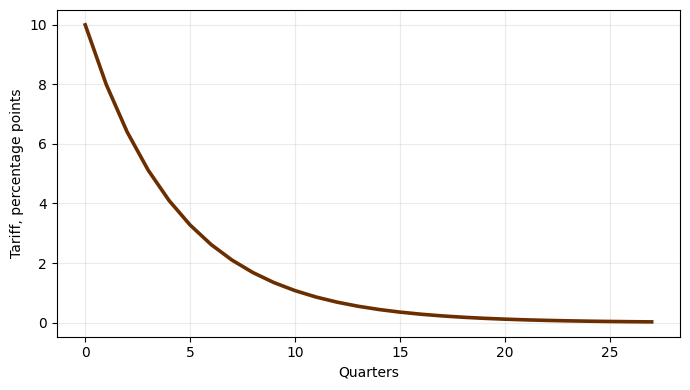

Saved: pe_figures/pe_impc_profile.png


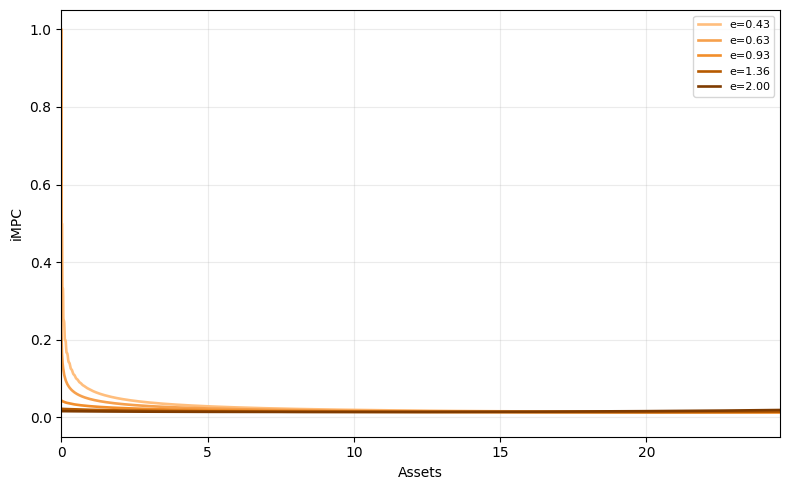

Saved: pe_figures/pe_aggregate_irfs.png


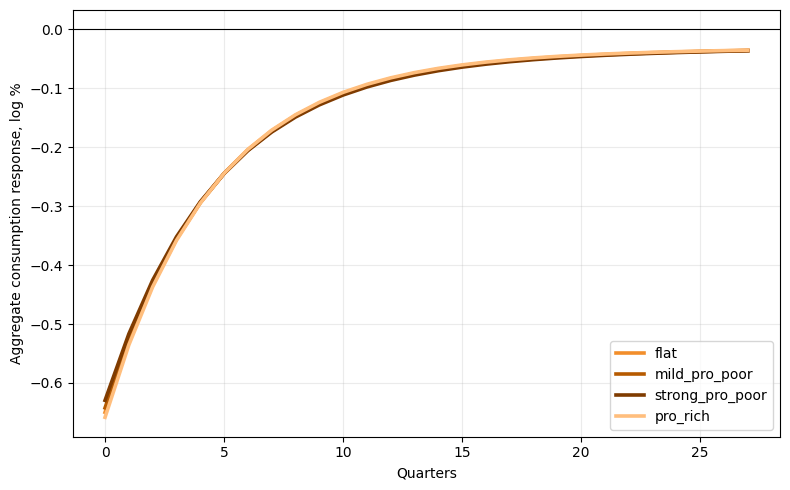

Saved: pe_figures/pe_aggregate_irfs_zoom.png


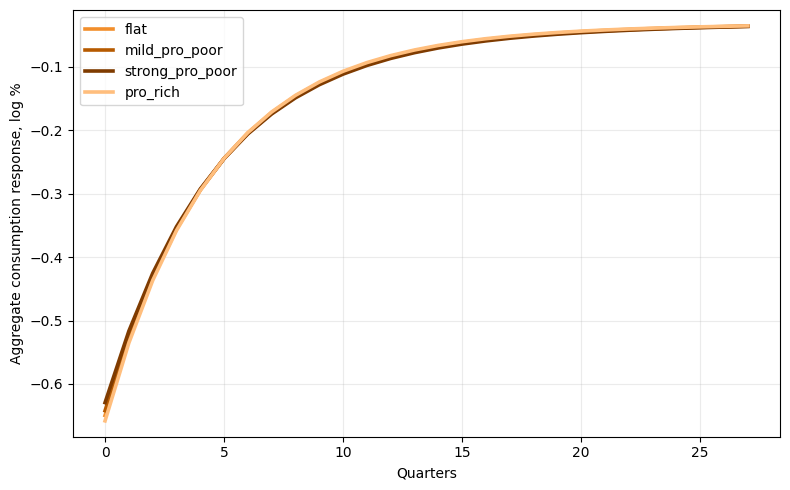

Saved: pe_figures/pe_gap_vs_flat.png


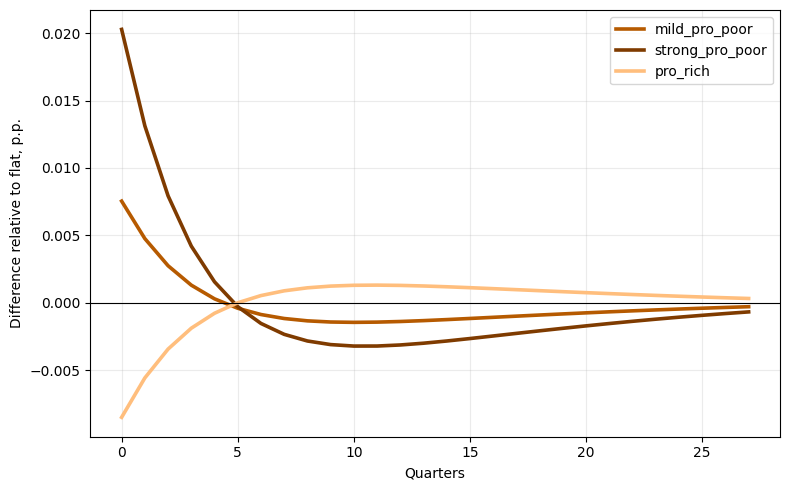

Saved: pe_figures/pe_sufficient_statistic.png


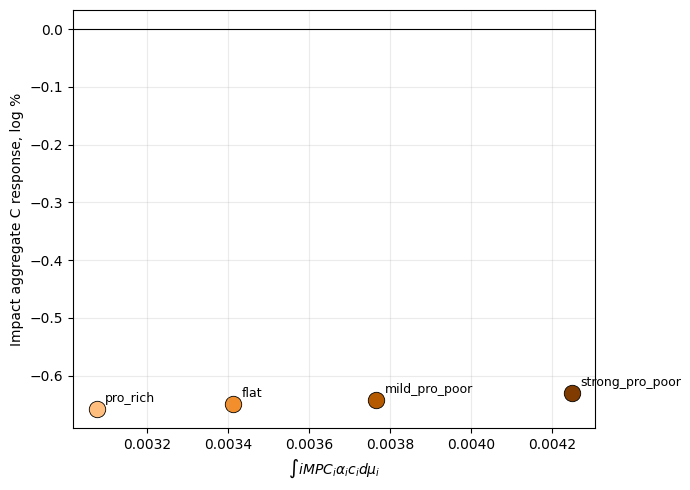

Saved: pe_figures/pe_burden_vs_sufficient.png


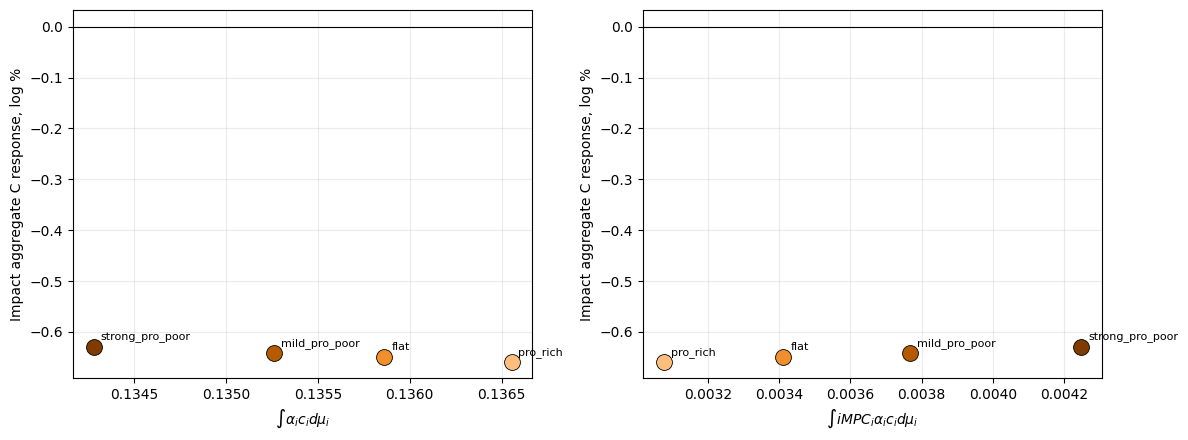

Saved: pe_figures/pe_distributional_mild_pro_poor.png


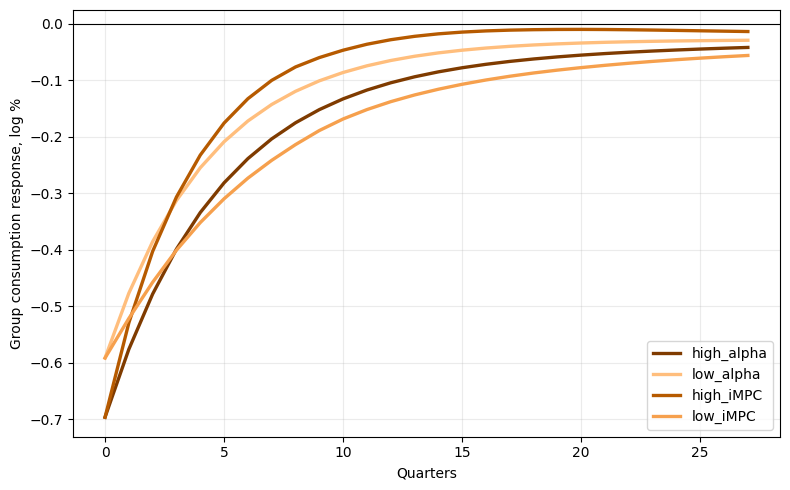

Saved: pe_figures/pe_distributional_strong_pro_poor.png


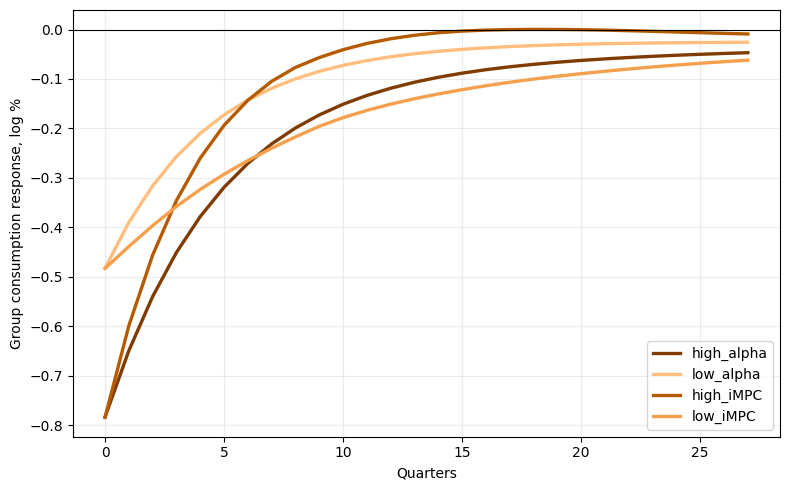

Saved: pe_figures/pe_mechanical_vs_optimal_mild_pro_poor.png


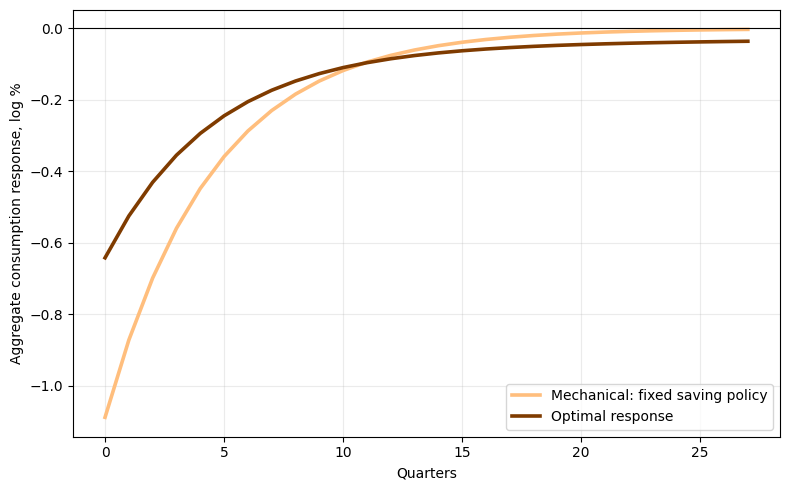


All figures saved in: pe_figures/


In [3]:
# ============================================================
# LIGHT FINAL SCRIPT WITH SAVED PNGs
# Partial-equilibrium HANK with tariff exposure
# EGM, US-style calibration, orange IRFs, no plot titles
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass


# ============================================================
# 0. Output folder
# ============================================================

FIG_DIR = "pe_figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


# ============================================================
# 1. Parameters
# ============================================================

@dataclass
class Params:
    # Preferences
    beta: float = 0.96 ** 0.25
    sigma: float = 2.0

    # Partial-equilibrium prices
    r: float = 0.01
    w: float = 1.0

    # Asset grid
    a_min: float = 0.0
    a_max: float = 40.0
    Na: int = 250
    a_curv: float = 3.0

    # Idiosyncratic income process
    Ne: int = 5
    rho_e: float = 0.95
    sigma_e: float = 0.12

    # Tariff shock
    T: int = 28
    tau0: float = 0.10
    rho_tau: float = 0.80

    # Numerical controls
    egm_tol: float = 1e-9
    egm_max_iter: int = 2500
    dist_tol: float = 1e-12
    dist_max_iter: int = 5000

    # iMPC perturbation
    transfer_eps: float = 1e-4

    # US-style average consumer import exposure
    alpha_bar: float = 0.11


# ============================================================
# 2. Orange palette and style
# ============================================================

ORANGE = {
    "flat": "#f28e2b",
    "mild_pro_poor": "#b65a00",
    "strong_pro_poor": "#7f3b00",
    "pro_rich": "#ffbe7d",
    "tariff": "#6b2e00",
    "high_alpha": "#7f3b00",
    "low_alpha": "#ffbe7d",
    "high_iMPC": "#b65a00",
    "low_iMPC": "#f6a04d",
    "mechanical": "#ffbe7d",
    "optimal": "#7f3b00",
}


def clean_axes(ax):
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.grid(alpha=0.25)
    return ax


# ============================================================
# 3. Basic tools
# ============================================================

def u_prime(c, p):
    return np.maximum(c, 1e-14) ** (-p.sigma)


def inv_u_prime(x, p):
    return np.maximum(x, 1e-14) ** (-1.0 / p.sigma)


def make_asset_grid(p):
    x = np.linspace(0.0, 1.0, p.Na)
    return p.a_min + (p.a_max - p.a_min) * x ** p.a_curv


def stationary_markov(P):
    n = P.shape[0]
    pi = np.ones(n) / n

    for _ in range(10000):
        new = pi @ P
        if np.max(np.abs(new - pi)) < 1e-14:
            return new
        pi = new

    return pi


def rouwenhorst(n, rho, sigma_eps):
    q = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        Pn = np.zeros((m, m))
        Pn[:-1, :-1] += q * P
        Pn[:-1, 1:] += (1.0 - q) * P
        Pn[1:, :-1] += (1.0 - q) * P
        Pn[1:, 1:] += q * P
        Pn[1:-1, :] /= 2.0
        P = Pn

    sigma_y = sigma_eps / np.sqrt(1.0 - rho ** 2)
    y_max = sigma_y * np.sqrt(n - 1.0)
    y = np.linspace(-y_max, y_max, n)
    e = np.exp(y)

    pi = stationary_markov(P)
    e = e / np.sum(pi * e)

    return e, P


def make_tau_path(p):
    t = np.arange(p.T)
    return p.tau0 * p.rho_tau ** t


# ============================================================
# 4. EGM household block
# ============================================================

def egm_step(c_next, tau_t, tau_next, A, E, Pi, alpha_grid, p):
    R = 1.0 + p.r
    Na, Ne, Nk = len(A), len(E), len(alpha_grid)

    c_now = np.empty((Na, Ne, Nk))
    a_pol = np.empty((Na, Ne, Nk))

    for k, alpha in enumerate(alpha_grid):
        P_t = 1.0 + alpha * tau_t
        P_next = 1.0 + alpha * tau_next

        for ie, e in enumerate(E):
            Emu = np.zeros(Na)

            for je in range(Ne):
                Emu += Pi[ie, je] * u_prime(c_next[:, je, k], p) / P_next

            c_endo = inv_u_prime(p.beta * R * P_t * Emu, p)
            a_endo = (P_t * c_endo + A - p.w * e) / R

            order = np.argsort(a_endo)
            a_endo = a_endo[order]
            c_endo = c_endo[order]

            c_interp = np.interp(
                A,
                a_endo,
                c_endo,
                left=np.nan,
                right=c_endo[-1],
            )

            constrained = np.isnan(c_interp)
            if np.any(constrained):
                c_interp[constrained] = (
                    R * A[constrained] + p.w * e - p.a_min
                ) / P_t

            a_next = R * A + p.w * e - P_t * c_interp
            a_next = np.clip(a_next, p.a_min, A[-1])

            c_interp = (R * A + p.w * e - a_next) / P_t
            c_interp = np.maximum(c_interp, 1e-14)

            c_now[:, ie, k] = c_interp
            a_pol[:, ie, k] = a_next

    return c_now, a_pol


def solve_ss_egm(A, E, Pi, p):
    alpha0 = np.array([0.0])
    R = 1.0 + p.r

    c = np.empty((len(A), len(E), 1))
    for ie, e in enumerate(E):
        c[:, ie, 0] = np.maximum(R * A + p.w * e - p.a_min, 1e-8)

    for it in range(p.egm_max_iter):
        c_new, a_pol = egm_step(c, 0.0, 0.0, A, E, Pi, alpha0, p)
        diff = np.max(np.abs(c_new - c))

        c = 0.9 * c_new + 0.1 * c

        if diff < p.egm_tol:
            print(f"SS EGM converged in {it + 1} iterations.")
            break

    return c[:, :, 0], a_pol[:, :, 0]


def solve_transition_egm(tau_path, c_terminal, A, E, Pi, alpha_grid, p):
    T = p.T
    c_next = np.repeat(c_terminal[:, :, None], len(alpha_grid), axis=2)

    c_list = [None] * T
    a_list = [None] * T

    tau_ext = np.append(tau_path, 0.0)

    for t in range(T - 1, -1, -1):
        c_t, a_t = egm_step(
            c_next,
            tau_ext[t],
            tau_ext[t + 1],
            A,
            E,
            Pi,
            alpha_grid,
            p,
        )

        c_list[t] = c_t
        a_list[t] = a_t
        c_next = c_t

    return c_list, a_list


# ============================================================
# 5. Distribution simulation
# ============================================================

def add_mass(new, mass, a_next, ie_next, k, A):
    if a_next <= A[0]:
        new[0, ie_next, k] += mass
        return

    if a_next >= A[-1]:
        new[-1, ie_next, k] += mass
        return

    j = np.searchsorted(A, a_next) - 1
    wh = (a_next - A[j]) / (A[j + 1] - A[j])
    wl = 1.0 - wh

    new[j, ie_next, k] += wl * mass
    new[j + 1, ie_next, k] += wh * mass


def stationary_dist_ae(a_pol_ss, A, E, Pi, p):
    Na, Ne = len(A), len(E)

    dist = np.zeros((Na, Ne, 1))
    dist[0, :, 0] = 1.0 / Ne

    for _ in range(p.dist_max_iter):
        new = np.zeros_like(dist)

        for ia in range(Na):
            for ie in range(Ne):
                mass = dist[ia, ie, 0]
                if mass == 0.0:
                    continue

                a_next = a_pol_ss[ia, ie]

                for je in range(Ne):
                    add_mass(new, mass * Pi[ie, je], a_next, je, 0, A)

        new /= new.sum()

        if np.max(np.abs(new - dist)) < p.dist_tol:
            return new[:, :, 0]

        dist = new

    return dist[:, :, 0]


def simulate_forward(joint0, c_list, a_list, A, E, Pi, p, c_ss, impc, alpha_grid, masks):
    T = p.T
    Na, Ne, Nk = joint0.shape

    dist = joint0.copy()

    alpha_arr = np.zeros_like(joint0)
    for k, alpha in enumerate(alpha_grid):
        alpha_arr[:, :, k] = alpha

    impc_arr = np.repeat(impc[:, :, None], Nk, axis=2)
    c_ss_arr = np.repeat(c_ss[:, :, None], Nk, axis=2)

    C = np.zeros(T)
    group_C = {name: np.zeros(T) for name in masks}
    moments = []

    for t in range(T):
        c_t = c_list[t]
        a_t = a_list[t]

        C[t] = np.sum(dist * c_t)

        weights_c = dist * c_ss_arr
        weights_c /= weights_c.sum()

        avg_alpha = np.sum(dist * alpha_arr)
        avg_alpha_cweighted = np.sum(weights_c * alpha_arr)
        avg_iMPC = np.sum(dist * impc_arr)

        tariff_burden_stat = np.sum(dist * alpha_arr * c_ss_arr)
        suff_cweighted = np.sum(dist * impc_arr * alpha_arr * c_ss_arr)

        cov_cweighted = (
            np.sum(weights_c * impc_arr * alpha_arr)
            - np.sum(weights_c * impc_arr) * np.sum(weights_c * alpha_arr)
        )

        moments.append({
            "avg_alpha": avg_alpha,
            "avg_alpha_cweighted": avg_alpha_cweighted,
            "avg_iMPC": avg_iMPC,
            "tariff_burden_stat": tariff_burden_stat,
            "suff_cweighted": suff_cweighted,
            "cov_iMPC_alpha_cweighted": cov_cweighted,
        })

        for name, mask in masks.items():
            group_C[name][t] = np.sum(dist * c_t * mask)

        new = np.zeros_like(dist)

        for ia in range(Na):
            for ie in range(Ne):
                for k in range(Nk):
                    mass = dist[ia, ie, k]
                    if mass == 0.0:
                        continue

                    a_next = a_t[ia, ie, k]

                    for je in range(Ne):
                        add_mass(new, mass * Pi[ie, je], a_next, je, k, A)

        dist = new / new.sum()

    return C, pd.DataFrame(moments), group_C


# ============================================================
# 6. iMPC and alpha assignment
# ============================================================

def interp_by_assets(policy, A, A_query):
    out = np.empty_like(policy)

    for ie in range(policy.shape[1]):
        out[:, ie] = np.interp(
            A_query,
            A,
            policy[:, ie],
            left=policy[0, ie],
            right=policy[-1, ie],
        )

    return out


def compute_impc(c_ss, A, p):
    R = 1.0 + p.r
    eps = p.transfer_eps

    A_shift = np.minimum(A + eps / R, A[-1])
    c_shift = interp_by_assets(c_ss, A, A_shift)

    impc = (c_shift - c_ss) / eps
    return np.clip(impc, 0.0, 1.0)


def alpha_profiles(p):
    profiles = {}

    profiles["flat"] = np.ones(10) * p.alpha_bar

    profiles["mild_pro_poor"] = np.array([
        0.090, 0.094, 0.098, 0.103, 0.107,
        0.113, 0.117, 0.122, 0.127, 0.132
    ])

    profiles["strong_pro_poor"] = np.array([
        0.060, 0.075, 0.088, 0.098, 0.105,
        0.115, 0.125, 0.138, 0.152, 0.164
    ])

    profiles["pro_rich"] = profiles["mild_pro_poor"][::-1]

    for key in profiles:
        profiles[key] = profiles[key] * (p.alpha_bar / profiles[key].mean())

    return profiles


def assign_alpha_by_impc_deciles(dist_ae, impc, alpha_profile):
    Na, Ne = dist_ae.shape
    Nk = 10

    joint = np.zeros((Na, Ne, Nk))

    states = []
    for ia in range(Na):
        for ie in range(Ne):
            mass = dist_ae[ia, ie]
            if mass > 0.0:
                states.append((impc[ia, ie], ia, ie, mass))

    states.sort(key=lambda x: x[0])

    target = np.ones(10) / 10.0
    decile = 0
    remaining_target = target[decile]

    for _, ia, ie, mass in states:
        remaining_state = mass

        while remaining_state > 1e-15 and decile < 10:
            alloc = min(remaining_state, remaining_target)
            joint[ia, ie, decile] += alloc

            remaining_state -= alloc
            remaining_target -= alloc

            if remaining_target <= 1e-14:
                decile += 1
                if decile < 10:
                    remaining_target = target[decile]

    joint /= joint.sum()
    return joint, alpha_profile.copy()


def make_masks(joint, alpha_grid, impc):
    Nk = len(alpha_grid)

    alpha_arr = np.zeros_like(joint)
    for k, alpha in enumerate(alpha_grid):
        alpha_arr[:, :, k] = alpha

    impc_arr = np.repeat(impc[:, :, None], Nk, axis=2)

    median_alpha = np.median(alpha_grid)

    values = impc_arr.flatten()
    weights = joint.flatten()

    order = np.argsort(values)
    cum = np.cumsum(weights[order])
    median_impc = values[order][np.searchsorted(cum, 0.5 * weights.sum())]

    return {
        "high_alpha": (alpha_arr >= median_alpha).astype(float),
        "low_alpha": (alpha_arr < median_alpha).astype(float),
        "high_iMPC": (impc_arr > median_impc).astype(float),
        "low_iMPC": (impc_arr <= median_impc).astype(float),
    }


# ============================================================
# 7. Mechanical counterfactual
# ============================================================

def mechanical_consumption(tau_path, a_zero, A, E, alpha_grid, p):
    R = 1.0 + p.r
    c_mech = []

    for t in range(p.T):
        c_t = np.empty_like(a_zero[t])

        for k, alpha in enumerate(alpha_grid):
            P_t = 1.0 + alpha * tau_path[t]

            for ie, e in enumerate(E):
                c_t[:, ie, k] = (R * A + p.w * e - a_zero[t][:, ie, k]) / P_t

        c_mech.append(np.maximum(c_t, 1e-14))

    return c_mech


# ============================================================
# 8. Run model
# ============================================================

def run_light_model(p):
    A = make_asset_grid(p)
    E, Pi = rouwenhorst(p.Ne, p.rho_e, p.sigma_e)

    c_ss, a_ss = solve_ss_egm(A, E, Pi, p)
    dist_ae = stationary_dist_ae(a_ss, A, E, Pi, p)
    impc = compute_impc(c_ss, A, p)

    profiles = alpha_profiles(p)

    alpha_union = np.unique(
        np.round(np.concatenate(list(profiles.values())), 12)
    )

    tau_zero = np.zeros(p.T)
    tau_shock = make_tau_path(p)

    print(f"Solving transitions for {len(alpha_union)} alpha values.")

    c_zero_union, a_zero_union = solve_transition_egm(
        tau_zero, c_ss, A, E, Pi, alpha_union, p
    )

    c_shock_union, a_shock_union = solve_transition_egm(
        tau_shock, c_ss, A, E, Pi, alpha_union, p
    )

    def select_slices(list_arr, alpha_grid):
        idx = []
        for alpha in alpha_grid:
            j = np.argmin(np.abs(alpha_union - alpha))
            idx.append(j)
        return [arr[:, :, idx] for arr in list_arr]

    irf_rows = []
    group_rows = []
    summary_rows = []
    alpha_rows = []

    for scenario, profile in profiles.items():
        alpha_grid = np.round(profile.copy(), 12)

        joint, alpha_grid = assign_alpha_by_impc_deciles(
            dist_ae, impc, alpha_grid
        )

        c_zero = select_slices(c_zero_union, alpha_grid)
        a_zero = select_slices(a_zero_union, alpha_grid)
        c_shock = select_slices(c_shock_union, alpha_grid)
        a_shock = select_slices(a_shock_union, alpha_grid)

        c_mech = mechanical_consumption(tau_shock, a_zero, A, E, alpha_grid, p)

        masks = make_masks(joint, alpha_grid, impc)

        C0, M0, G0 = simulate_forward(
            joint, c_zero, a_zero, A, E, Pi, p, c_ss, impc, alpha_grid, masks
        )

        C1, M1, G1 = simulate_forward(
            joint, c_shock, a_shock, A, E, Pi, p, c_ss, impc, alpha_grid, masks
        )

        CM, MM, GM = simulate_forward(
            joint, c_mech, a_zero, A, E, Pi, p, c_ss, impc, alpha_grid, masks
        )

        C_irf = 100.0 * (np.log(C1) - np.log(C0))
        C_mech_irf = 100.0 * (np.log(CM) - np.log(C0))

        for t in range(p.T):
            irf_rows.append({
                "scenario": scenario,
                "quarter": t,
                "C_irf": C_irf[t],
                "C_mechanical_irf": C_mech_irf[t],
                "tau_pp": 100.0 * tau_shock[t],
            })

            for group in masks:
                group_rows.append({
                    "scenario": scenario,
                    "quarter": t,
                    "group": group,
                    "group_C_irf": 100.0 * (
                        np.log(G1[group][t]) - np.log(G0[group][t])
                    ),
                })

        m = M1.iloc[0]

        summary_rows.append({
            "scenario": scenario,
            "impact_C": C_irf[0],
            "trough_C": C_irf.min(),
            "cumulative_C_loss": 100.0 * np.sum(C1 - C0) / C0[0],
            "avg_alpha": m["avg_alpha"],
            "avg_alpha_cweighted": m["avg_alpha_cweighted"],
            "avg_iMPC": m["avg_iMPC"],
            "tariff_burden_stat": m["tariff_burden_stat"],
            "suff_cweighted": m["suff_cweighted"],
            "cov_iMPC_alpha_cweighted": m["cov_iMPC_alpha_cweighted"],
        })

        for k, alpha in enumerate(alpha_grid):
            alpha_rows.append({
                "scenario": scenario,
                "decile": k + 1,
                "alpha": alpha,
            })

    return {
        "params": p,
        "A": A,
        "E": E,
        "Pi": Pi,
        "c_ss": c_ss,
        "a_ss": a_ss,
        "dist_ae": dist_ae,
        "iMPC": impc,
        "irfs": pd.DataFrame(irf_rows),
        "group_irfs": pd.DataFrame(group_rows),
        "summary": pd.DataFrame(summary_rows),
        "alpha_profiles": pd.DataFrame(alpha_rows),
    }


# ============================================================
# 9. Tables
# ============================================================

def show_summary(out):
    s = out["summary"].copy()
    flat = s.loc[s["scenario"] == "flat", "impact_C"].iloc[0]
    s["impact_relative_to_flat"] = s["impact_C"] / flat

    cols = [
        "scenario",
        "impact_C",
        "impact_relative_to_flat",
        "trough_C",
        "cumulative_C_loss",
        "avg_alpha",
        "avg_alpha_cweighted",
        "tariff_burden_stat",
        "suff_cweighted",
        "cov_iMPC_alpha_cweighted",
    ]

    return s[cols].round(6)


# ============================================================
# 10. Figures: no titles, saved PNGs
# ============================================================

def plot_alpha_profiles(out):
    df = out["alpha_profiles"]
    fig, ax = plt.subplots(figsize=(8, 5))

    order = ["flat", "mild_pro_poor", "strong_pro_poor", "pro_rich"]

    for scenario in order:
        temp = df[df["scenario"] == scenario]
        ax.plot(
            temp["decile"],
            temp["alpha"],
            marker="o",
            linewidth=2.3,
            color=ORANGE[scenario],
            label=scenario,
        )

    ax.set_xlabel("iMPC decile, low to high")
    ax.set_ylabel(r"Import exposure $\alpha_i$")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    savefig(fig, "pe_alpha_profiles.png")
    plt.show()


def plot_tariff(out):
    df = out["irfs"]
    temp = df[df["scenario"] == df["scenario"].iloc[0]]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(
        temp["quarter"],
        temp["tau_pp"],
        linewidth=2.6,
        color=ORANGE["tariff"],
    )

    ax.set_xlabel("Quarters")
    ax.set_ylabel("Tariff, percentage points")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    savefig(fig, "pe_tariff_path.png")
    plt.show()


def plot_impc(out):
    A = out["A"]
    E = out["E"]
    impc = out["iMPC"]

    fig, ax = plt.subplots(figsize=(8, 5))

    shades = ["#ffbe7d", "#f6a04d", "#f28e2b", "#b65a00", "#7f3b00"]

    for ie, e in enumerate(E):
        ax.plot(
            A,
            impc[:, ie],
            linewidth=1.9,
            color=shades[min(ie, len(shades) - 1)],
            label=f"e={e:.2f}",
        )

    ax.set_xlim(0, np.percentile(A, 85))
    ax.set_xlabel("Assets")
    ax.set_ylabel("iMPC")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    savefig(fig, "pe_impc_profile.png")
    plt.show()


def plot_irfs(out):
    df = out["irfs"]
    fig, ax = plt.subplots(figsize=(8, 5))

    order = ["flat", "mild_pro_poor", "strong_pro_poor", "pro_rich"]

    for scenario in order:
        temp = df[df["scenario"] == scenario]
        ax.plot(
            temp["quarter"],
            temp["C_irf"],
            linewidth=2.6,
            color=ORANGE[scenario],
            label=scenario,
        )

    clean_axes(ax)
    ax.set_xlabel("Quarters")
    ax.set_ylabel("Aggregate consumption response, log %")
    ax.legend()
    fig.tight_layout()
    savefig(fig, "pe_aggregate_irfs.png")
    plt.show()


def plot_irfs_zoom(out):
    df = out["irfs"]
    fig, ax = plt.subplots(figsize=(8, 5))

    order = ["flat", "mild_pro_poor", "strong_pro_poor", "pro_rich"]

    for scenario in order:
        temp = df[df["scenario"] == scenario]
        ax.plot(
            temp["quarter"],
            temp["C_irf"],
            linewidth=2.6,
            color=ORANGE[scenario],
            label=scenario,
        )

    clean_axes(ax)
    ax.set_xlabel("Quarters")
    ax.set_ylabel("Aggregate consumption response, log %")
    ax.set_ylim(df["C_irf"].min() - 0.025, df["C_irf"].max() + 0.025)
    ax.legend()
    fig.tight_layout()
    savefig(fig, "pe_aggregate_irfs_zoom.png")
    plt.show()


def plot_irf_gaps_vs_flat(out):
    df = out["irfs"].copy()

    flat = df[df["scenario"] == "flat"][["quarter", "C_irf"]].rename(
        columns={"C_irf": "C_flat"}
    )

    df = df.merge(flat, on="quarter")
    df["gap_vs_flat"] = df["C_irf"] - df["C_flat"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for scenario in ["mild_pro_poor", "strong_pro_poor", "pro_rich"]:
        temp = df[df["scenario"] == scenario]
        ax.plot(
            temp["quarter"],
            temp["gap_vs_flat"],
            linewidth=2.6,
            color=ORANGE[scenario],
            label=scenario,
        )

    clean_axes(ax)
    ax.set_xlabel("Quarters")
    ax.set_ylabel("Difference relative to flat, p.p.")
    ax.legend()
    fig.tight_layout()
    savefig(fig, "pe_gap_vs_flat.png")
    plt.show()


def plot_sufficient(out):
    s = out["summary"]
    fig, ax = plt.subplots(figsize=(7, 5))

    for _, row in s.iterrows():
        scenario = row["scenario"]

        ax.scatter(
            row["suff_cweighted"],
            row["impact_C"],
            s=140,
            color=ORANGE[scenario],
            edgecolor="black",
            linewidth=0.6,
        )

        ax.annotate(
            scenario,
            (row["suff_cweighted"], row["impact_C"]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9,
        )

    clean_axes(ax)
    ax.set_xlabel(r"$\int iMPC_i \alpha_i c_i d\mu_i$")
    ax.set_ylabel("Impact aggregate C response, log %")
    fig.tight_layout()
    savefig(fig, "pe_sufficient_statistic.png")
    plt.show()


def plot_burden_vs_sufficient(out):
    s = out["summary"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    for _, row in s.iterrows():
        scenario = row["scenario"]

        ax[0].scatter(
            row["tariff_burden_stat"],
            row["impact_C"],
            s=130,
            color=ORANGE[scenario],
            edgecolor="black",
            linewidth=0.6,
        )

        ax[0].annotate(
            scenario,
            (row["tariff_burden_stat"], row["impact_C"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

        ax[1].scatter(
            row["suff_cweighted"],
            row["impact_C"],
            s=130,
            color=ORANGE[scenario],
            edgecolor="black",
            linewidth=0.6,
        )

        ax[1].annotate(
            scenario,
            (row["suff_cweighted"], row["impact_C"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    clean_axes(ax[0])
    clean_axes(ax[1])

    ax[0].set_xlabel(r"$\int \alpha_i c_i d\mu_i$")
    ax[0].set_ylabel("Impact aggregate C response, log %")

    ax[1].set_xlabel(r"$\int iMPC_i \alpha_i c_i d\mu_i$")
    ax[1].set_ylabel("Impact aggregate C response, log %")

    fig.tight_layout()
    savefig(fig, "pe_burden_vs_sufficient.png")
    plt.show()


def plot_distributional(out, scenario="mild_pro_poor"):
    df = out["group_irfs"]
    temp = df[df["scenario"] == scenario]

    fig, ax = plt.subplots(figsize=(8, 5))

    for group in ["high_alpha", "low_alpha", "high_iMPC", "low_iMPC"]:
        tg = temp[temp["group"] == group]

        ax.plot(
            tg["quarter"],
            tg["group_C_irf"],
            linewidth=2.4,
            color=ORANGE[group],
            label=group,
        )

    clean_axes(ax)
    ax.set_xlabel("Quarters")
    ax.set_ylabel("Group consumption response, log %")
    ax.legend()
    fig.tight_layout()
    savefig(fig, f"pe_distributional_{scenario}.png")
    plt.show()


def plot_mechanical_vs_optimal(out, scenario="mild_pro_poor"):
    df = out["irfs"]
    temp = df[df["scenario"] == scenario]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        temp["quarter"],
        temp["C_mechanical_irf"],
        linewidth=2.6,
        color=ORANGE["mechanical"],
        label="Mechanical: fixed saving policy",
    )

    ax.plot(
        temp["quarter"],
        temp["C_irf"],
        linewidth=2.6,
        color=ORANGE["optimal"],
        label="Optimal response",
    )

    clean_axes(ax)
    ax.set_xlabel("Quarters")
    ax.set_ylabel("Aggregate consumption response, log %")
    ax.legend()
    fig.tight_layout()
    savefig(fig, f"pe_mechanical_vs_optimal_{scenario}.png")
    plt.show()


# ============================================================
# 11. Execute
# ============================================================

p = Params()
out = run_light_model(p)

print("\nMain summary:")
display(show_summary(out))

plot_alpha_profiles(out)
plot_tariff(out)
plot_impc(out)
plot_irfs(out)
plot_irfs_zoom(out)
plot_irf_gaps_vs_flat(out)
plot_sufficient(out)
plot_burden_vs_sufficient(out)
plot_distributional(out, scenario="mild_pro_poor")
plot_distributional(out, scenario="strong_pro_poor")
plot_mechanical_vs_optimal(out, scenario="mild_pro_poor")

print(f"\nAll figures saved in: {FIG_DIR}/")